### **Google Search Analysis Project** 

### **Finding the Five Task :** 
1) First, write a code where, by changing just the keyword, we can search for multiple things.
2) Top 15 countries where the keywords are searched the most, and also create visual representation of it.
3) A world map needs to be plotted showing the countries that search the keyword the most.
4) We need to extract the time-wise interest of the keyword — how it trended in different years.
5) Compare related keywords and plot the graph.

In [12]:
# Installing the pytrends Library
!pip install pytrends


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\sagar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
# step 1: Importing Required Libraries : 
import pandas as pd                      
import numpy as np 
import plotly as px
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq

#### **Task 1 :  First, write a code where, by changing just the keyword, we can search for multiple things.**

In [14]:
# Pytrend Setup and Keyword defining
pytrends = TrendReq(hl ='en-US' , tz=360)
keyword = "Machine Learning"


In [15]:
# Data Request 
pytrends.build_payload([keyword] , cat=0 , timeframe='today 12-m',geo='', gprop='')

#### **Task 2 : Top 15 countries where the keywords are searched the most, and also create visual representation of it.**

In [16]:
# Country wise Interest 
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by=keyword , ascending=False).head(15)

C:\Users\sagar\AppData\Local\Temp\ipykernel_14892\117034022.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




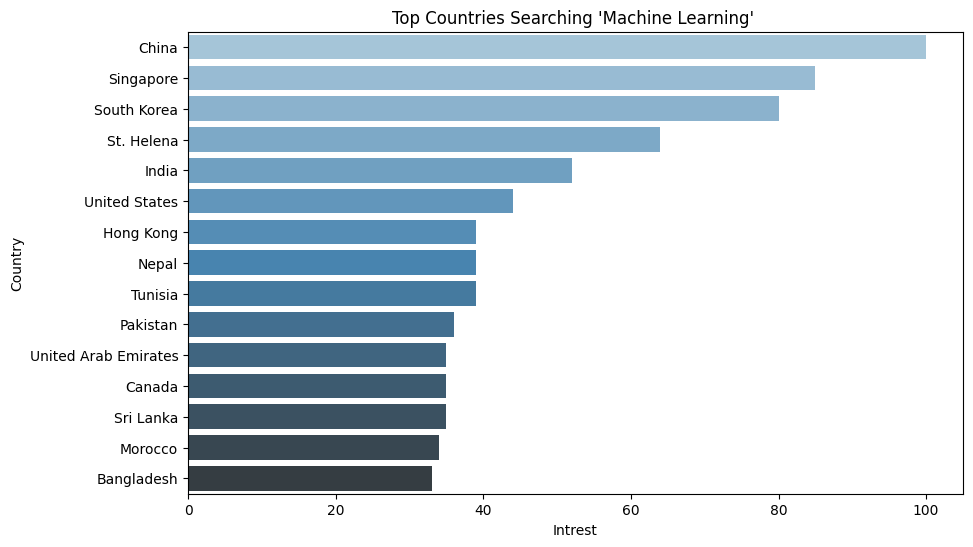

In [17]:
# Creating Bar Plot 
plt.figure(figsize=(10,6))
sns.barplot(x=region_data[keyword] , y=region_data.index , palette="Blues_d")
plt.title(f"Top Countries Searching '{keyword}' ")
plt.xlabel("Intrest")
plt.ylabel("Country")
plt.savefig("images/Top Countries Searching.png")
plt.show()

#### **Task 3 : A world map needs to be plotted showing the countries that search the keyword the most.**

In [18]:
import plotly.express as px

region_data = region_data.reset_index()

fig = px.choropleth(
    region_data,
    locations="geoName",
    locationmode="country names",
    color=keyword,
    title=f"Search Interest for '{keyword}' by Country",
    color_continuous_scale="Blues"
)

# Save
fig.write_html("images/search_interest_country.html")

# Show
fig.show()

#### **Task 4 : We need to extract the time-wise interest of the keyword — how it trended in different years.**

In [19]:
time_df = pytrends.interest_over_time()

C:\Users\sagar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytrends\request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



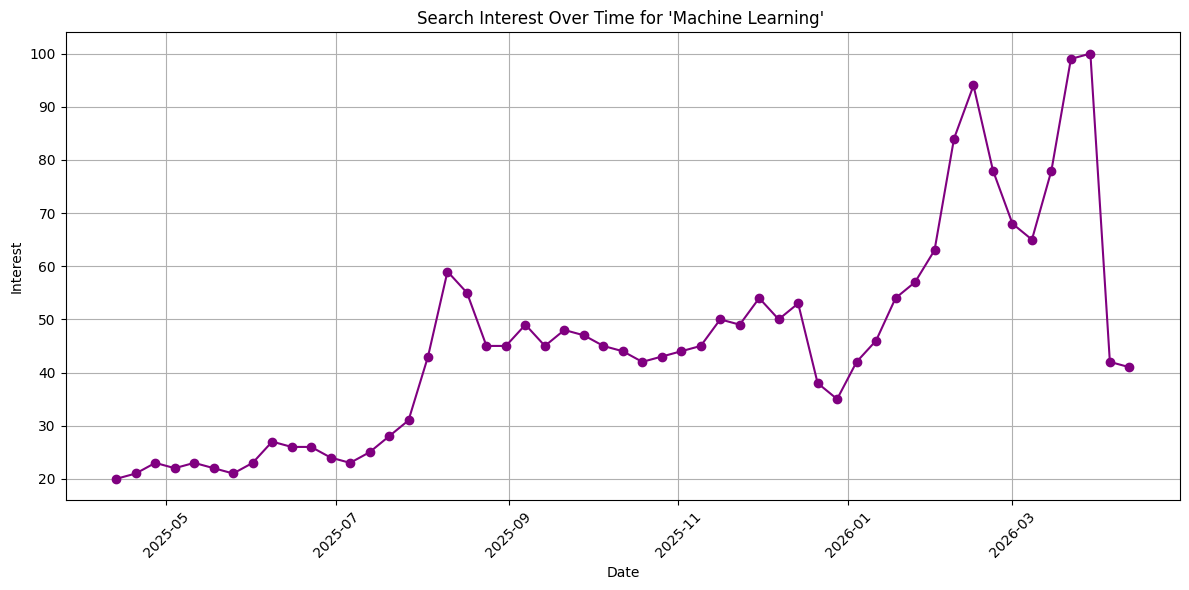

In [20]:
# Line Plot (Search Trend Over Time )
plt.figure(figsize=(12,6))
plt.plot(time_df.index , time_df[keyword] , marker = 'o' , color = 'purple')
plt.title(f"Search Interest Over Time for '{keyword}' ")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)
plt.savefig("images/Search Trend Over Time.png")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Task 5: Compare related keywords and plot the graph.**

In [21]:
kw_list = ["Machine Learning" , "Data Science" , "AI Engineer" , "AI Architecture"]
pytrends.build_payload(kw_list , cat=0 , timeframe='today 12-m', geo = '', gprop='')

C:\Users\sagar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytrends\request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



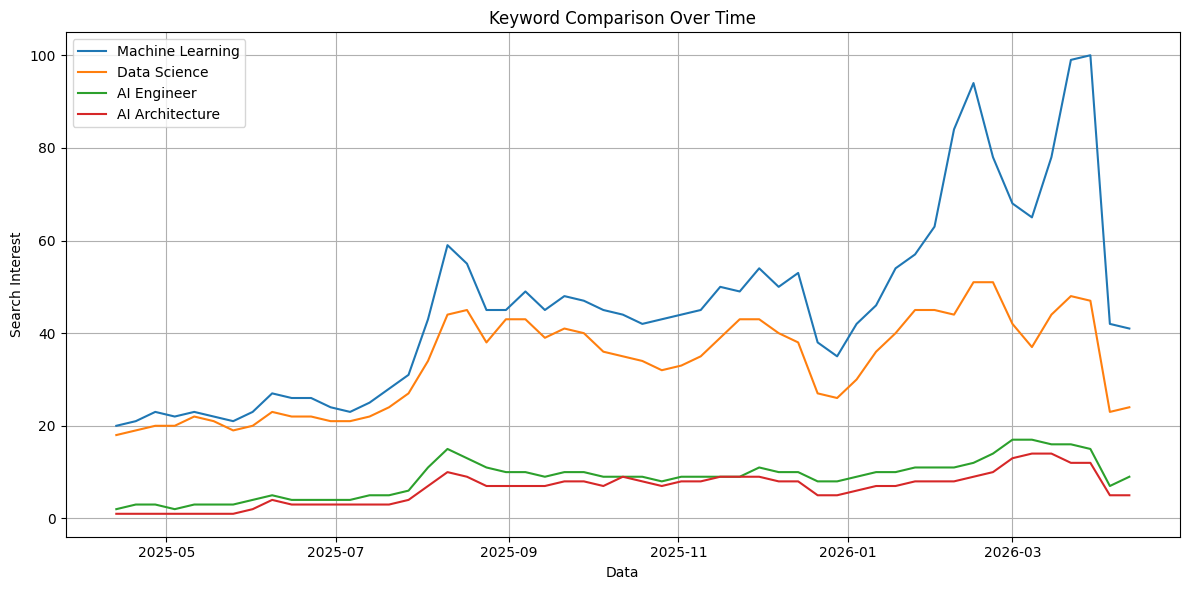

In [22]:
# Comparison Plot (Line Plot of All 4 keywords)

compare_df = pytrends.interest_over_time()

plt.figure(figsize=(12,6))
for kw in kw_list:
    plt.plot(compare_df.index , compare_df[kw] , label=kw)
    
plt.title("Keyword Comparison Over Time")
plt.xlabel("Data")
plt.ylabel("Search Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/Keyword Comparison Over Time.png")
plt.show()